# Get non bonded potential energy

In [1]:
import molsysmt as msm
msm.configure.set_default_standard_units(standards=['nm', 'ps', 'K', 'mole', 'amu', 'e',
                                      'kcal/mol', 'kcal/(mol*nm**2)', 'N', 'degrees'])

In [2]:
molecular_system = msm.convert(msm.systems['Barnase-Barstar']['barnase_barstar.h5msm'])

In [3]:
msm.info(molecular_system, element='molecule')

index,name,type,n atoms,n groups,n components,chain index,entity index,entity name
0,BARNASE,protein,1727,110,1,0,0,protein 0
1,BARSTAR,protein,1432,89,1,0,1,protein 1


In [4]:
U1nb2 = msm.molecular_mechanics.get_non_bonded_potential_energy(molecular_system,
                                                              selection='molecule_name=="BARNASE"',
                                                              selection_2='molecule_name=="BARSTAR"')

In [5]:
U1nb2

<Quantity(-773.319028, 'kilocalorie / mole')>

In [6]:
U12 = msm.molecular_mechanics.get_potential_energy(molecular_system)
U1 = msm.molecular_mechanics.get_potential_energy(molecular_system, selection='molecule_name=="BARNASE"')
U2 = msm.molecular_mechanics.get_potential_energy(molecular_system, selection='molecule_name=="BARSTAR"')

In [7]:
U12-U1-U2

<Quantity(-773.31879, 'kilocalorie / mole')>

In [8]:
U12_groups = msm.molecular_mechanics.get_non_bonded_potential_energy(molecular_system,
                                                              selection='all in groups of group_index in [0,1,2]',
                                                              selection_2='all in groups of group_index in [100,101,102]')

In [9]:
U12_groups.shape

(3, 3)

In [10]:
U12_groups = msm.molecular_mechanics.get_non_bonded_potential_energy(molecular_system,
                                                              selection='all in groups of molecule_name=="BARNASE"',
                                                              selection_2='all in groups of molecule_name=="BARSTAR"')

In [11]:
U12_groups

Magnitude,[[21.68926459881361 8.221779196713667 0.0209469636670718 ... -0.09186122117717224 0.01822745545017899 -7.045808046999214] [-0.9174121269532417 -0.2834135897984696 0.0006666488902746605 ... 0.004798116921010938 0.00037463741594754755 0.20017541845259657] [0.32055537513747495 0.1024525206585915 0.0004887858665696066 ... -0.0025865374343117154 0.0007936435379478035 -0.08429988620386068] ... [17.317502266134458 7.526426196782101 0.050855631339939915 ... -0.11013901078392968 0.087919536386795 -7.604848586350508] [0.25965487068065 0.09783552549990385 0.00036003719836874597 ... -0.0027373938840844205 0.0014332627047806126 -0.09035420235438739] [-0.10560621039133454 -0.2673570330238707 0.0034983253843629786 ... 0.00913466823716804 -0.016754033688573134 0.49273416143530413]]
Units,kilocalorie/mole


MOLSYSMT WARNING | UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.



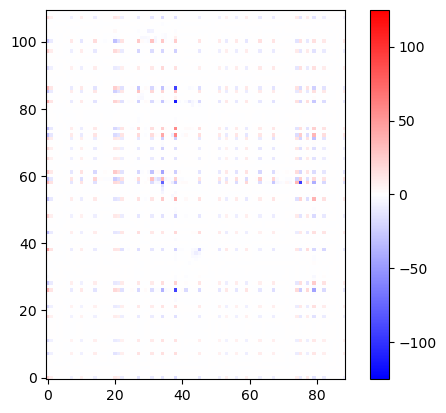

In [12]:
import matplotlib.pyplot as plt

plt.imshow(U12_groups, origin='lower', cmap='bwr', vmin=-125, vmax=125)
plt.colorbar()
plt.show()

MOLSYSMT WARNING | UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.



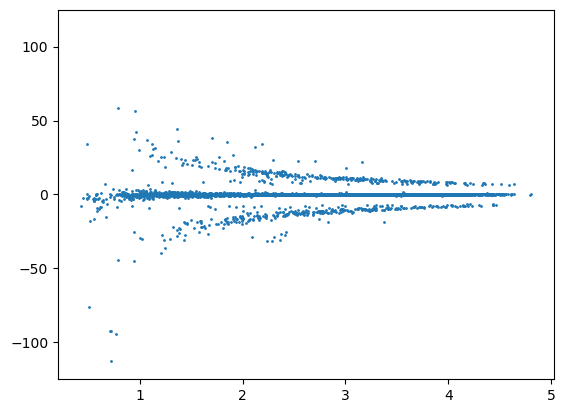

In [13]:
distance = msm.structure.get_distances(molecular_system, selection='all in groups of molecule_name=="BARNASE"',
                 selection_2='all in groups of molecule_name=="BARSTAR"')

plt.scatter(distance.flatten(), U12_groups.flatten(), s=1.0)
plt.ylim([-125.0, 125.0])
plt.show()

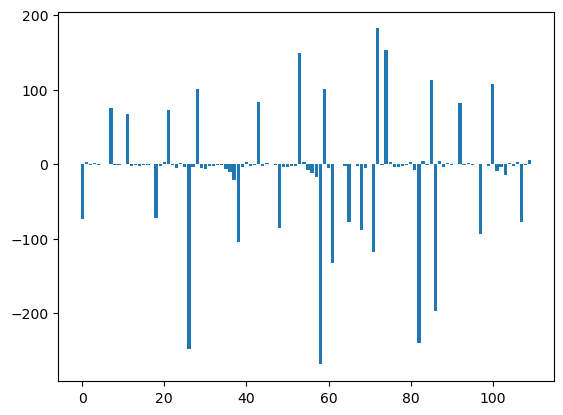

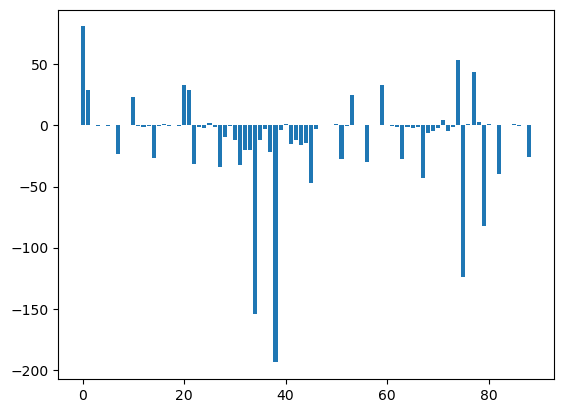

In [14]:
import numpy as np

U12_1_groups= U12_groups.sum(axis=1)
U12_2_groups= U12_groups.sum(axis=0)

plt.bar(np.arange(U12_1_groups.shape[0]), msm.pyunitwizard.get_value(U12_1_groups))
plt.show()

plt.bar(np.arange(U12_2_groups.shape[0]), msm.pyunitwizard.get_value(U12_2_groups))
plt.show()

In [15]:
aux = [ii for ii in msm.pyunitwizard.get_value(U12_1_groups)]
aux += [ii for ii in msm.pyunitwizard.get_value(U12_2_groups)]
aux = np.array(aux)
max_abs_val = max(abs(aux.min()), abs(aux.max()))

view = msm.view(molecular_system)
view.clear()
view.add_cartoon(selection='all')
msm.thirds.nglview.set_color_by_value(view, aux, mid_value=0.0, cmap='bwr_r')
view

NGLWidget()